# Teoria

Celem analizy czynnikowej (FA) jest znalezienie wspólnych czynników $f$, które wpływają na  zmienne $x$. Jest to - w pewnym sensie - forma redukcji wymiarowości, podobna do PCA. Różnica polega na tym, że
- PCA jest zorientowana na dane: zmniejsza wymiar zwykle przez rzutowanie danych na przestrzeń tego niższego wymiaru, bez konieczności rozumienia tych nowych wymiarów. PCA wykonujemy po prostu by uzyskać dane o niższym wymiarze.
- FA jest zorientowana na model: redukuje wymiar, ale nacisk jest położony nie na zmniejszenie wymiaru, ale na  znaczenie tych nowych wymiarów - to co one reprezentują. Celem jest uzyskanie modelu, który może wyjaśnić dane. 

PCA i FA różnią się podejściem matematycznym do problemu
- PCA znajduje nowe osie, które maksymalizują wariancję danych
- FA szuka ukrytych zmiennych (wspólne czynniki - **common factors**), które najlepiej wyjaśniają dane za pomocą hipotetycznego modelu
- FA w pewnym sensie zawiera technikę PCA, gdyż jednym ze sposobów znalezienia ukrytych zmiennych w FA jest wykonanie PCA
- W PCA jest tylko jedno rozwiązanie, w FA jest nieskończenie wiele rozwiązań (przekształcenia ortogonalne, np. obroty, rozwiązania dają nowe rozwiązanie)
- mimo różnic PCA i FA często prowadzą do bardzo podobnych wyników

Historyczne zastosowania FA:
- $x$ to wyniki różnych testów (wiedzy, inteligencji, rozwiązywania problemów itp.), a $f$ to różne rodzaje inteligencji (Spearman)
- $x$ to zestaw pytań psychologicznych, a $f$ to cechy osobowości (tzw. wielka piątka cech osobowości)
- $x$ to zestaw różnych cen akcji, a $f$ to różne branże

#### Model liniowy
Każda obserwacja jest liniową kombinacją pewnych czynników:
$$
x_j-\mu_j=l_{j 1} f_1+\cdots+l_{j m} f_m+\varepsilon_j, \quad j=1 \ldots p
$$
W notacji macierzowej:
$$
x-\mu=L \cdot f+\varepsilon
$$
gdzie
* $x=(x_1,\dots,x_p)$ to wektor losowy
* $\mu=(\mu_1,\dots,\mu_p)$ to średnia $\mathbb{E}x$
* $\varepsilon=(\varepsilon_1,\dots,\varepsilon_p)$ to błędy (**specific factors**)
* $f=(f_1,\dots,f_m)$ to tzw. czynniki (**common factors**); zwykle $m \ll p$
* $L$ to macierz $(p \times m)$ znana jako „macierz wzorców” (**loadings**, **loading matirix**, **pattern matrix**)


Obrazowe zastosowanie FA do danych z restauracji.
<img src="FA.png" alt = "Cloud Image" width=" 40% " height = " 40% " title = "Cloud title" >

Wróćmy do liniowej zależności między zmiennymi a czynnikami
$$
x_j-\mu_j=l_{j 1} f_1+\cdots+l_{j m} f_m+\varepsilon_j, \quad j=1 \ldots p
$$
Przypomina to model regresji
$$
y-\beta_0 = \beta_1 x_1+\cdots+\beta_m x_m+\varepsilon
$$
Porównajmy FA i regresję:
- W regresji $y$ jest zwykle liczbą (wektor wymiaru 1), tymczasem $x$ to wektor $p$-wymiarowy. W regresji  współczynniki tworzą wektor, podczas gdy w FA współczynniki tworzą macierz. (Istnieje również model regresji wielokrotnej, więc zwróćmy uwagę na inne różnice.)
- W regresji mamy $x$ to zmienne niezależne, podczas gdy w FA $f$ to czynniki
- W regresji $x$ jest znane (dane obserwowane), podczas gdy tutaj $f$ jest nieznane i jest tylko konstruktem teoretycznym
- Z perspektywy Machine Learningu: regresja jest przykładem uczenia nadzorowanego (do tego służą wartości $y$), podczas gdy FA jest przykładem uczenia nienadzorowanego.

#### Model czynnikowy
Dodatkowe założenia:
- $\mathbb{E}[f]=0$ oraz $\text{cov}[f]=\mathbb{E}\left[f f^T\right]=I$ (macierz przekątniowa $m\times m$), co oznacza, że czynniki $f_1,\dots,f_m$ są wzajemnie nieskorelowane
- $\mathbb{E}[\epsilon]=0$, $\text{cov}[\epsilon]=\mathbb{E}\left[\epsilon \epsilon^T\right]=\Psi$ (macierz  przekątniowa $p\times p$), czyli $\epsilon_1,\dots,\epsilon_p$ są nieskorelowane
- $\text{cov}(\epsilon, f)=\mathbb{E}\left[\epsilon f_T^T\right]=0$, czyli błędy i czynniki są niezależne. Zatem
$\text{cov}\left(\epsilon_j, f_h\right)=\mathbb{E}\left[\epsilon_j f_h\right]-\mathbb{E}\left[\epsilon_j\right] \mathbb{E} \left[f_h\right]=\mathbb{E}\left[\epsilon_j f_h\right]$

Na podstawie tych założeń struktura kowariancji $x$ jest następująca:
$$
\Sigma= \text{cov}[x]=\mathbb{E}\left[(x-\mu)(x-\mu)^T\right]=\mathbb{E}\left[(L f+ \epsilon)(L f+\epsilon)^T\right]=\mathbb{E}\left[L f f^T L^T+L f \epsilon^T+\epsilon f^T L^T+\epsilon \epsilon^T\right] 
$$
$$
=L \mathbb{E}\left[f f^T\right] L^T+L \mathbb{E}\left[f \epsilon^T\right]+\mathbb{E}\left[\epsilon f ^T\right] L^T+\mathbb{E}\left[\epsilon \epsilon^T\right]=L L^T+\Psi 
$$
Stąd
$$
\text{cov}[x]=\Sigma=L L^T+\Psi
$$
Patrząc na wartości na przekątnej  po obu stronach, otrzymujemy:
$$
\sigma_j^2=l_{j 1}^2+\cdots l_{j m}^2+\psi_j
$$
Możemy również obliczyć kowariancję między $x$ a $f$: 
$$
\text{cov}(x, f)=\text{cov}(x-\mu, f)=\text{cov}(L f+\epsilon, f)=\mathbb{E}\left[(L f+\epsilon) f^T\right]-0 \cdot 0=L \mathbb{E}\left[f f^T\right]+\mathbb{E}\left[\epsilon f^T\right]=L
$$

#### Estymowanie parametrów modelu czynnikowego z danych
Do tej pory mówiliśmy o modelu teoretycznym.
Załóżmy, że mamy dane i chcemy oszacować parametry modelu.

W modelu 
$$
x_j-\mu_j=l_{j 1} f_1+\cdots+l_{j m} f_m+\varepsilon_j, \quad j=1 \ldots p
$$
znamy $x_j$. Trzeba wyestymować parametry $\mu=(\mu_1,\dots,\mu_p)$, $L=(l_{ji})_{j\leq p, i\leq m}$, $f_1,\dots,f_m$ oraz $\Psi$

##### Estymacja $\mu$

Szacowanie $\mu$ jest proste, to średnia $\mu=\bar{x}$ estymator nieobciążony wartości średniej.

##### Estymacja $L$ i $\Psi$

Na początek estymujemy macierz kowariancji $\Sigma$ następująco
$\hat{\Sigma}=\frac{1}{\mathrm{n}-1}(X-\mu)^T(X-\mu)$

Do oszcowania $L$ i $\Psi$ użyjemy PCA:
- (SVD - rozkład według wartości własnych) Macierz kowariancji danych $\Sigma$ można przedstawić jako $\Sigma=Q \Lambda Q^T$, gdzie $Q$ jest macierzą ortogonalną, a $\Lambda$ jest macierzą diagonalną, której wszystkie wartości są nieujemne.
- Możemy ustawić kolejność wartości własnych od największej do najmniejszej
$\lambda_1 \geq \cdots \geq \lambda_p \geq 0$. Możemy założyć, że 
$\Sigma = Q \Lambda Q^T=\sum \lambda_i q_i q_i^T$
- Ponieważ wszystkie wartości własne są nieujemne, to możemy wziąć ich pierwiastek kwadratowy:
$\Lambda=\Lambda^{0.5} \Lambda^{0.5}$
- $\Sigma=Q \Lambda^{0,5} \Lambda^{0,5} Q^T=\left(Q \Lambda^{0,5}\right)\left(Q \Lambda^{0,5}\right)^T =\tilde{Q} \tilde{Q}^T$
- Jeśli teraz weźmiemy tylko pierwsze $m$ największych wartości własnych i wektorów własnych, to otrzymamy macierz  $(p \times m)$. To będzie estmator $L$. Wówczas
$\Sigma \approx L L^T$. 
- Teraz możemy obliczyć $\Psi=\Sigma-L L^T$, czyli
$\psi_j=\sigma_j^2-(l_{j 1}^2+\cdots +l_{j m}^2)$

- Możemy obliczyć proporcję wyjaśnionej wariancji:
$\frac{\sum_{j=1}^m \lambda_j}{\sum_{j=1}^p \lambda_j}$. 

Jest to prawie identyczne porównując do PCA:
- W FA $L=Q \Lambda^{0.5}$, podczas gdy w PCA zwykle bierzemy tylko $Q$
- W PCA używamy $Q$ do projekcji danych; w przypadku FA odkładamy dane na bok, zależy nam teraz na zrozumieniu czynników poprzez analizę $L$.

##### Estymacja $f$

Zakładamy, że łączny rozkład $x$ i $f$ jest normalny:
$$
\left(\begin{array}{l}
x \\
f
\end{array}\right) \sim N\left(\left(\begin{array}{c}
\mu \\
0
\end{array}\right),\left(\begin{array}{cc}
\Sigma & L \\
L^T & I
\end{array}\right)\right)
$$
Możemy teraz użyć reguł rozkładu warunkowego, aby znaleźć rozkład $f \mid x$.
Formuła ogólna jest następująca. Jeśli $$\left(\begin{array}{l}x \\ y\end{array}\right) \sim \mathcal{N}\left(\left(\begin{array}{l}\mu_x \\ \mu_y\end{array}\right),\left[\begin{array}{cc}\Sigma_{x x} & \Sigma_{x y} \\ \Sigma_{y x} & \Sigma_{y y}\end {array}\right]\right),$$
to
$$y \mid x \sim \mathcal{N}\left(\mu_y+\Sigma_{y x} \Sigma_{x x}^{-1}\left(x-\mu_x\right), \Sigma_{y y}-\Sigma_{y x} \Sigma_{x x}^{-1} \Sigma_{x y}\right).$$
Zatem w naszym przypadku: $f \mid x \sim N\left(\mu^*, \Sigma^*\right)$ gdzie:
$$
\mu^*=L^T \Sigma^{-1}\left(x-\mu\right), \quad \Sigma^*=I-L^T \Sigma^{-1 } \mathrm{~L}
$$
Połóżmy $\hat{f}_i=\mu_i^*$.

### Przykład - 25 Personality items
https://vincentarelbundock.github.io/Rdatasets/doc/psych/bfi.html

##### A — Agreeableness (Ugodowość)
* A1: Jestem obojętny na uczucia innych.
* A2: Pytam innych, jak się czują.
* A3: Potrafię pocieszać.
* A4: Kocham dzieci.
* A5: Sprawiam, że ludzie czują się swobodnie.

##### C — Conscientiousness (Sumienność)
* C1: Jestem wymagający wobec swojej pracy.
* C2: Kontynuuję pracę, aż wszystko będzie perfekcyjne.
* C3: Działam zgodnie z planem.
* C4: Robię rzeczy byle jak. (odwrócony)
* C5: Marnuję czas. (odwrócony)

##### E — Extraversion (Ekstrawersja)
* E1: Niewiele mówię. (odwrócony)
* E2: Trudno mi podejść do innych. (odwrócony)
* E3: Potrafię przyciągać ludzi.
* E4: Łatwo nawiązuję znajomości.
* E5: Przejmuję inicjatywę.

##### N — Neuroticism (Neurotyczność)
* N1: Łatwo się złoszczę.
* N2: Łatwo się irytuję.
* N3: Mam częste zmiany nastroju.
* N4: Często mam chandrę.
* N5: Łatwo panikuję.

##### O — Openness to Experience (Otwartość)
* O1: Mam mnóstwo pomysłów.
* O2: Unikam trudnych tekstów. (odwrócony)
* O3: Podnoszę poziom rozmowy.
* O4: Lubię rozmyślać.
* O5: Nie zagłębiam się w temat. (odwrócony)

In [1]:
# biblioteka przeznaczona do analizy czynnikowej
from factor_analyzer import FactorAnalyzer
# pozostałe, standardowe biblioteki
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("bfi.csv")
df

,Unnamed: 0,A1,A2,A3,A4,A5,C1,C2,C3,C4,...,N4,N5,O1,O2,O3,O4,O5,gender,education,age
0,61617,2.0,4.0,3.0,4.0,4.0,2.0,3.0,3.0,4.0,...,2.0,3.0,3.0,6,3.0,4.0,3.0,1,NaN,16
1,61618,2.0,4.0,5.0,2.0,5.0,5.0,4.0,4.0,3.0,...,5.0,5.0,4.0,2,4.0,3.0,3.0,2,NaN,18
2,61620,5.0,4.0,5.0,4.0,4.0,4.0,5.0,4.0,2.0,...,2.0,3.0,4.0,2,5.0,5.0,2.0,2,NaN,17
3,61621,4.0,4.0,6.0,5.0,5.0,4.0,4.0,3.0,5.0,...,4.0,1.0,3.0,3,4.0,3.0,5.0,2,NaN,17
4,61622,2.0,3.0,3.0,4.0,5.0,4.0,4.0,5.0,3.0,...,4.0,3.0,3.0,3,4.0,3.0,3.0,1,NaN,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,67551,6.0,1.0,3.0,3.0,3.0,6.0,6.0,6.0,1.0,...,NaN,1.0,6.0,1,6.0,6.0,1.0,1,3.0,19
2796,67552,2.0,4.0,4.0,3.0,5.0,2.0,3.0,4.0,4.0,...,3.0,3.0,6.0,3,5.0,4.0,2.0,1,4.0,27
2797,67556,2.0,3.0,5.0,2.0,5.0,5.0,5.0,5.0,1.0,...,3.0,1.0,5.0,1,6.0,4.0,3.0,2,4.0,29
2798,67559,5.0,2.0,2.0,4.0,4.0,5.0,5.0,5.0,2.0,...,4.0,1.0,5.0,2,5.0,5.0,1.0,1,4.0,31


In [3]:
df.columns

Index(['Unnamed: 0', 'A1', 'A2', 'A3', 'A4', 'A5', 'C1', 'C2', 'C3', 'C4',
       'C5', 'E1', 'E2', 'E3', 'E4', 'E5', 'N1', 'N2', 'N3', 'N4', 'N5', 'O1',
       'O2', 'O3', 'O4', 'O5', 'gender', 'education', 'age'],
      dtype='object')

In [4]:
df.drop(['Unnamed: 0','gender', 'education', 'age'],axis=1,inplace=True)

In [5]:
df.dropna(inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2436 entries, 0 to 2799
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      2436 non-null   float64
 1   A2      2436 non-null   float64
 2   A3      2436 non-null   float64
 3   A4      2436 non-null   float64
 4   A5      2436 non-null   float64
 5   C1      2436 non-null   float64
 6   C2      2436 non-null   float64
 7   C3      2436 non-null   float64
 8   C4      2436 non-null   float64
 9   C5      2436 non-null   float64
 10  E1      2436 non-null   float64
 11  E2      2436 non-null   float64
 12  E3      2436 non-null   float64
 13  E4      2436 non-null   float64
 14  E5      2436 non-null   float64
 15  N1      2436 non-null   float64
 16  N2      2436 non-null   float64
 17  N3      2436 non-null   float64
 18  N4      2436 non-null   float64
 19  N5      2436 non-null   float64
 20  O1      2436 non-null   float64
 21  O2      2436 non-null   int64  
 22  O3   

In [7]:
df.head()

,A1,A2,A3,A4,A5,C1,C2,C3,C4,C5,...,N1,N2,N3,N4,N5,O1,O2,O3,O4,O5
0,2.0,4.0,3.0,4.0,4.0,2.0,3.0,3.0,4.0,4.0,...,3.0,4.0,2.0,2.0,3.0,3.0,6,3.0,4.0,3.0
1,2.0,4.0,5.0,2.0,5.0,5.0,4.0,4.0,3.0,4.0,...,3.0,3.0,3.0,5.0,5.0,4.0,2,4.0,3.0,3.0
2,5.0,4.0,5.0,4.0,4.0,4.0,5.0,4.0,2.0,5.0,...,4.0,5.0,4.0,2.0,3.0,4.0,2,5.0,5.0,2.0
3,4.0,4.0,6.0,5.0,5.0,4.0,4.0,3.0,5.0,5.0,...,2.0,5.0,2.0,4.0,1.0,3.0,3,4.0,3.0,5.0
4,2.0,3.0,3.0,4.0,5.0,4.0,4.0,5.0,3.0,2.0,...,2.0,3.0,4.0,4.0,3.0,3.0,3,4.0,3.0,3.0


##### Test Bartletta.

W analizie czynnikowej zakładamy, że zmienne są ze sobą skorelowane, a zmienność tą opisują czynniki wpólne (**common factors**)
* $H_0$: Macierz korelacji populacji to macierz jednostkowa $I$ brak korelacji  
* $H_1$ : Macierz korelacji populacji nie jest równa $I$ - dalsza analiza ma sens

Wzór na test sferyczności Bartletta jest następujący:
$$
-1 *(n-1-((2 p+5) / 6)) * \ln (\operatorname{det}(R))
$$
Gdzie $\operatorname{det}(R)$ to wyznacznik macierzy korelacji, a $p$ to liczba zmiennych.

In [8]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value,p_value=calculate_bartlett_sphericity(df)
print('Wartość p dla testu Bartletta wynosi: ',p_value)

Wartość p dla testu Bartletta wynosi:  0.0


##### Kryterium Kaisera-Meyera-Olkina.
Kryterium Kaisera-Meyera-Olkina (KMO) jest miarą stosowaną w analizie czynnikowej do oceny adekwatności doboru próby i przydatności danych do analizy czynnikowej. Statystyka KMO mieści się w zakresie od 0 do 1, przy czym wartości bliższe 1 wskazują na lepszą przydatność do analizy czynnikowej.

Interpretacja statystyki KMO:
* KMO$\leq$0,5 - obserwowane zmienne nie nadają się do analizy czynnikowej.
* KMO między 0,5 a 0,6 - marginalną przydatność.
* KMO między 0,6 a 0,7 - niewielka przydatność.
* KMO między 0,7 a 0,8 - dobra przydatność.
* KMO między 0,8 a 0,9 - bardzo dobra przydatność.
* KMO powyżej 0,9 - idealna doskonałą przydatność do analizy czynnikowej.


In [9]:
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all,kmo_model=calculate_kmo(df)
kmo_all, kmo_model

(array([0.7540716 , 0.83643198, 0.87020241, 0.87804164, 0.90355905,
        0.84336264, 0.7958161 , 0.85197217, 0.8265898 , 0.86411332,
        0.83813017, 0.88388974, 0.89704594, 0.87740109, 0.89339981,
        0.7794802 , 0.78039095, 0.86239667, 0.88526811, 0.86024031,
        0.8586864 , 0.78033877, 0.84445746, 0.77017696, 0.76159382]),
 0.8486452309468383)

In [10]:
kmo_all = pd.DataFrame(kmo_all, index=df.columns, columns=['KMO'])
kmo_model = pd.DataFrame(kmo_model, index=['Model'], columns=['KMO'])
kmo = pd.concat([kmo_all,kmo_model], axis=0)
kmo

,KMO
A1,0.754072
A2,0.836432
A3,0.870202
A4,0.878042
A5,0.903559
C1,0.843363
C2,0.795816
C3,0.851972
C4,0.826590
C5,0.864113


In [11]:
# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(n_factors=25,rotation=None)
fa.fit(df)
# 
ev, v = fa.get_eigenvalues()
ev


array([5.13431118, 2.75188667, 2.14270195, 1.85232761, 1.54816285,
       1.07358247, 0.83953893, 0.79920618, 0.71898919, 0.68808879,
       0.67637336, 0.65179984, 0.62325295, 0.59656284, 0.56309083,
       0.54330533, 0.51451752, 0.49450315, 0.48263952, 0.448921  ,
       0.42336611, 0.40067145, 0.38780448, 0.38185679, 0.26253902])

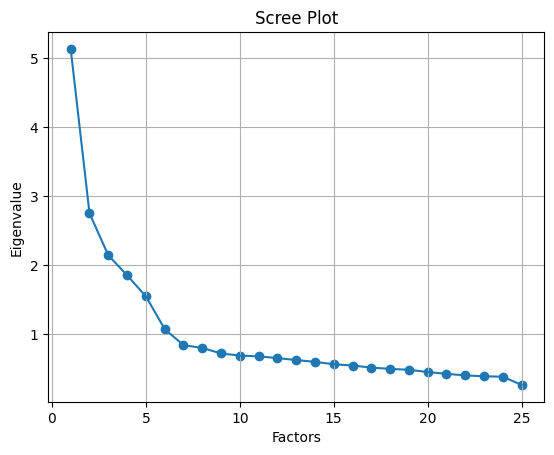

In [12]:
# Create scree plot using matplotlib
plt.scatter(range(1,df.shape[1]+1),ev)
plt.plot(range(1,df.shape[1]+1),ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

In [13]:
# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(n_factors=6,rotation="varimax")
fa.fit(df)

FactorAnalyzer(n_factors=6, rotation='varimax', rotation_kwargs={})

In [14]:
loadings_df = pd.DataFrame(fa.loadings_, index=df.columns, columns=['F1', 'F2', 'F3', 'F4', 'F5', 'F6'])
loadings_df

,F1,F2,F3,F4,F5,F6
A1,0.095220,0.040783,0.048734,-0.530987,-0.113057,0.161216
A2,0.033131,0.235538,0.133714,0.661141,0.063734,-0.006244
A3,-0.009621,0.343008,0.121353,0.605933,0.033990,0.160106
A4,-0.081518,0.219717,0.235140,0.404594,-0.125338,0.086356
A5,-0.149616,0.414458,0.106382,0.469698,0.030977,0.236519
C1,-0.004358,0.077248,0.554582,0.007511,0.190124,0.095035
C2,0.068330,0.038370,0.674545,0.057055,0.087593,0.152775
C3,-0.039994,0.031867,0.551164,0.101282,-0.011338,0.008996
C4,0.216283,-0.066241,-0.638475,-0.102617,-0.143846,0.318359
C5,0.284187,-0.180812,-0.544838,-0.059955,0.025837,0.132423


In [15]:
# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(n_factors=5,rotation="varimax")
fa.fit(df)

FactorAnalyzer(n_factors=5, rotation='varimax', rotation_kwargs={})

In [16]:
loadings_df5 = pd.DataFrame(fa.loadings_, index=df.columns, columns=['F1', 'F2', 'F3', 'F4', 'F5'])
loadings_df5

,F1,F2,F3,F4,F5
A1,0.111126,0.040465,0.022798,-0.428166,-0.077931
A2,0.029588,0.213716,0.139037,0.626946,0.062139
A3,0.009357,0.317848,0.109331,0.650743,0.056196
A4,-0.066476,0.204566,0.230584,0.435624,-0.112700
A5,-0.122113,0.393034,0.087869,0.537087,0.066708
C1,0.010416,0.070184,0.545824,0.038878,0.209584
C2,0.089574,0.033270,0.648731,0.102782,0.115434
C3,-0.030855,0.023907,0.557036,0.111578,-0.005183
C4,0.240410,-0.064984,-0.633806,-0.037498,-0.107535
C5,0.290318,-0.176395,-0.562467,-0.047525,0.036822


Interpretacja:
* czynnik F1 ma wysokie wartości czynników dla N1,N2,N3,N4 i N5 (neurotyzm - Neuroticism) 
* czynnik F2 ma wysokie wartości czynników dla E1, E2, E3, E4 i E5 (ekstrawersja - Extraversion)
* czynnik F3 ma wysokie wartości czynników dla C1,C2,C3,C4 i C5 (sumienność - Conscientiousness)
* czynnik F4 ma wysokie wartości czynników dla A1, A2, A3, A4 i A5 (ugodowość - Agreeableness)
* czynnik F5 ma wysokie wartości czynników dla O1, O2, O3, O4 i O5 (otwartość - Opennness)

Wariancja $j$-tej zmiennej wynosi $\sigma_j^2=l_{j 1}^2+\cdots l_{j m}^2+\psi_j$

W analizie czynnikowej **communalities** reprezentują proporcję zmienności każdej obserwowanej zmiennej tłumaczoną przez czynniki wspólne **common factors**. Są one obliczane jako suma kwadratów czynników wspólnych dla każdej zmiennej  $=l_{j 1}^2+\cdots l_{j m}^2$



In [17]:
communalities = fa.get_communalities()

**uniquenesses** $\psi_j$ to część wariancji $j$-tej zmiennej związanej z rozkładem błędu $\varepsilon_j$.  

In [18]:
uniquenesses = fa.get_uniquenesses()

In [19]:
communalities_df = pd.DataFrame(communalities, index=df.columns, columns=['communalities'])
uniquenesses_df = pd.DataFrame(uniquenesses, index=df.columns, columns=['uniquenesses'])
variance = pd.concat([communalities_df,uniquenesses_df], axis=1)
variance

,communalities,uniquenesses
A1,0.203905,0.796095
A2,0.462803,0.537197
A3,0.539692,0.460308
A4,0.301905,0.698095
A5,0.470020,0.529980
C1,0.348395,0.651605
C2,0.453872,0.546128
C3,0.324289,0.675711
C4,0.476699,0.523301
C5,0.435383,0.564617


In [20]:
pd.DataFrame(fa.transform(df), columns=['neurotyzm', 'ekstrawersja', 'sumienność', 'ugodowość', 'otwartość'])

,neurotyzm,ekstrawersja,sumienność,ugodowość,otwartość
0,-0.439830,0.103897,-1.216713,-0.696215,-1.519449
1,0.084369,0.559311,-0.601521,-0.189341,-0.248384
2,0.520534,0.318235,0.025646,-0.751136,0.204503
3,-0.197064,0.057696,-1.019263,0.064286,-1.029492
4,-0.329835,0.408754,-0.058843,-0.820454,-0.691042
...,...,...,...,...,...
2431,1.308046,-1.152403,-0.104197,-1.146411,0.412042
2432,0.732472,0.252206,-0.587511,-0.317781,1.025564
2433,-0.223267,0.721169,0.787110,-1.058480,0.925103
2434,0.920520,0.749337,0.070953,-2.135145,0.673460


### Hausing data

In [21]:
df= pd.read_csv('housing_data_sample.csv')
df

,Id,LotArea,YearBuilt,FullBath,TotRmsAbvGrd,GarageArea,1stFlrSF,2ndFlrSF,SalePrice
0,1,8450,2003,2,8,548,856,854,208500
1,2,9600,1976,2,6,460,1262,0,181500
2,3,11250,2001,2,6,608,920,866,223500
3,4,9550,1915,1,7,642,961,756,140000
4,5,14260,2000,2,9,836,1145,1053,250000
...,...,...,...,...,...,...,...,...,...
1455,1456,7917,1999,2,7,460,953,694,175000
1456,1457,13175,1978,2,7,500,2073,0,210000
1457,1458,9042,1941,2,9,252,1188,1152,266500
1458,1459,9717,1950,1,5,240,1078,0,142125


In [22]:
df.drop(['Id','SalePrice'],axis=1,inplace=True)
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   LotArea       1460 non-null   int64
 1   YearBuilt     1460 non-null   int64
 2   FullBath      1460 non-null   int64
 3   TotRmsAbvGrd  1460 non-null   int64
 4   GarageArea    1460 non-null   int64
 5   1stFlrSF      1460 non-null   int64
 6   2ndFlrSF      1460 non-null   int64
dtypes: int64(7)
memory usage: 80.0 KB


In [23]:
df.head()

,LotArea,YearBuilt,FullBath,TotRmsAbvGrd,GarageArea,1stFlrSF,2ndFlrSF
0,8450,2003,2,8,548,856,854
1,9600,1976,2,6,460,1262,0
2,11250,2001,2,6,608,920,866
3,9550,1915,1,7,642,961,756
4,14260,2000,2,9,836,1145,1053


In [24]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value,p_value=calculate_bartlett_sphericity(df)
print('Wartość p dla testu Bartletta wynosi: ',p_value)

Wartość p dla testu Bartletta wynosi:  0.0


In [25]:
kmo_all,kmo_model=calculate_kmo(df)
kmo_all = pd.DataFrame(kmo_all, index=df.columns, columns=['KMO'])
kmo_model = pd.DataFrame(kmo_model, index=['Model'], columns=['KMO'])
kmo = pd.concat([kmo_all,kmo_model], axis=0)
kmo

,KMO
LotArea,0.708672
YearBuilt,0.594179
FullBath,0.738779
TotRmsAbvGrd,0.542264
GarageArea,0.726127
1stFlrSF,0.423790
2ndFlrSF,0.365374
Model,0.547960


### Bike rental

In [26]:
df= pd.read_csv('bike_rentals.csv')
df

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1.0,0.0,1.0,0.0,6.0,0.0,2,0.344167,0.363625,0.805833,0.160446,985
1,2,1.0,0.0,1.0,0.0,0.0,0.0,2,0.363478,0.353739,0.696087,0.248539,801
2,3,1.0,0.0,1.0,0.0,1.0,1.0,1,0.196364,0.189405,0.437273,0.248309,1349
3,4,1.0,0.0,1.0,0.0,2.0,1.0,1,0.200000,0.212122,0.590435,0.160296,1562
4,5,1.0,0.0,1.0,0.0,3.0,1.0,1,0.226957,0.229270,0.436957,0.186900,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,1.0,1.0,12.0,0.0,4.0,1.0,2,0.254167,0.226642,0.652917,0.350133,2114
727,728,1.0,1.0,12.0,0.0,5.0,1.0,2,0.253333,0.255046,0.590000,0.155471,3095
728,729,1.0,1.0,12.0,0.0,6.0,0.0,2,0.253333,0.242400,0.752917,0.124383,1341
729,730,1.0,1.0,12.0,0.0,0.0,0.0,1,0.255833,0.231700,0.483333,0.350754,1796


In [27]:
df.drop(['instant'],axis=1,inplace=True)
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    float64
 1   yr          731 non-null    float64
 2   mnth        731 non-null    float64
 3   holiday     731 non-null    float64
 4   weekday     731 non-null    float64
 5   workingday  731 non-null    float64
 6   weathersit  731 non-null    int64  
 7   temp        731 non-null    float64
 8   atemp       731 non-null    float64
 9   hum         731 non-null    float64
 10  windspeed   731 non-null    float64
 11  cnt         731 non-null    int64  
dtypes: float64(10), int64(2)
memory usage: 68.7 KB


In [28]:
chi_square_value,p_value=calculate_bartlett_sphericity(df)
print('Wartość p dla testu Bartletta wynosi: ',p_value)

Wartość p dla testu Bartletta wynosi:  0.0


In [29]:
kmo_all,kmo_model=calculate_kmo(df)
kmo_all = pd.DataFrame(kmo_all, index=df.columns, columns=['KMO'])
kmo_model = pd.DataFrame(kmo_model, index=['Model'], columns=['KMO'])
kmo = pd.concat([kmo_all,kmo_model], axis=0)
kmo

,KMO
season,0.589824
yr,0.311830
mnth,0.593965
holiday,0.494085
weekday,0.205288
workingday,0.534083
weathersit,0.474898
temp,0.614540
atemp,0.617121
hum,0.555564


### Test na makiawelizm
https://www.kaggle.com/datasets/lucasgreenwell/machivallianism-test-responses

In [30]:
mak = pd.read_csv('Machivallianism.csv', sep='\t')
mak.tail()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,screenw,screenh,hand,religion,orientation,race,voted,married,familysize,major
73484,2.0,17.0,9925.0,1.0,6.0,14218.0,2.0,16.0,25499.0,4.0,...,2048.0,1080.0,1,12,1,10,2,2,1,business
73485,5.0,9.0,5816.0,5.0,4.0,4368.0,1.0,15.0,7246.0,1.0,...,1440.0,900.0,1,2,3,60,2,1,2,sociology
73486,2.0,17.0,5353.0,1.0,18.0,6846.0,1.0,9.0,4920.0,1.0,...,1280.0,1024.0,1,1,1,60,2,1,3,NaN
73487,4.0,15.0,7974.0,3.0,9.0,7901.0,5.0,17.0,8647.0,3.0,...,414.0,736.0,1,3,1,10,1,1,4,Business
73488,3.0,12.0,7567.0,1.0,10.0,5766.0,5.0,13.0,37103.0,1.0,...,1366.0,768.0,1,4,1,70,2,1,4,NaN


In [31]:
col=[]
for i in range(1,21):
    col.append('Q'+str(i)+'A')
mak20=mak[col]

In [32]:
mak20.dropna(inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_19964\1169399028.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mak20.dropna(inplace=True)


In [33]:
mak20.head()

,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,Q11A,Q12A,Q13A,Q14A,Q15A,Q16A,Q17A,Q18A,Q19A,Q20A
0,3.0,3.0,5.0,2.0,3.0,1.0,2.0,4.0,3.0,3.0,1.0,5.0,4.0,1.0,5.0,2.0,4.0,4.0,4.0,4.0
1,5.0,5.0,1.0,3.0,5.0,1.0,1.0,4.0,2.0,1.0,1.0,5.0,5.0,2.0,5.0,1.0,2.0,4.0,5.0,3.0
2,5.0,5.0,1.0,1.0,5.0,1.0,1.0,5.0,1.0,1.0,1.0,5.0,5.0,1.0,5.0,1.0,1.0,5.0,5.0,3.0
3,2.0,4.0,2.0,1.0,5.0,1.0,3.0,2.0,4.0,2.0,1.0,5.0,1.0,1.0,4.0,1.0,1.0,5.0,3.0,4.0
4,5.0,5.0,2.0,1.0,2.0,1.0,2.0,4.0,2.0,2.0,1.0,4.0,4.0,1.0,5.0,1.0,1.0,4.0,5.0,1.0


In [34]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value,p_value=calculate_bartlett_sphericity(mak20)
print('Wartość p dla testu Bartletta wynosi: ',p_value)

Wartość p dla testu Bartletta wynosi:  0.0


In [35]:
kmo_all,kmo_model=calculate_kmo(mak20)
kmo_all = pd.DataFrame(kmo_all, index=mak20.columns, columns=['KMO'])
kmo_model = pd.DataFrame(kmo_model, index=['Model'], columns=['KMO'])
kmo = pd.concat([kmo_all,kmo_model], axis=0)
kmo

,KMO
Q1A,0.946843
Q2A,0.948917
Q3A,0.949011
Q4A,0.937773
Q5A,0.947963
Q6A,0.923903
Q7A,0.908895
Q8A,0.955126
Q9A,0.951895
Q10A,0.958013


In [36]:
# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(n_factors=20,rotation=None)
fa.fit(mak20)
ev, v = fa.get_eigenvalues()


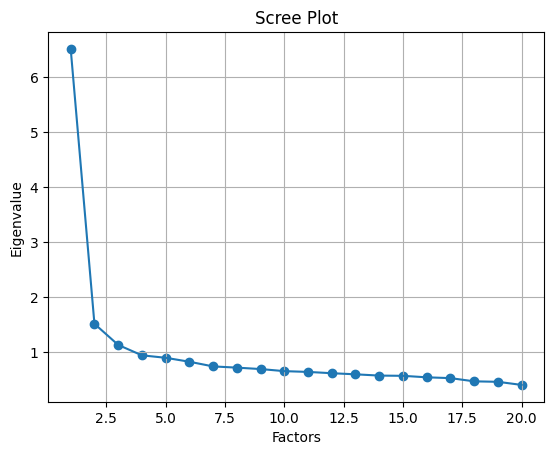

In [37]:
# Create scree plot using matplotlib
plt.scatter(range(1,mak20.shape[1]+1),ev)
plt.plot(range(1,mak20.shape[1]+1),ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

In [38]:
# Create factor analysis object and perform factor analysis
fa3 = FactorAnalyzer(n_factors=3,rotation="varimax")
fa3.fit(mak20)

FactorAnalyzer(rotation='varimax', rotation_kwargs={})

In [44]:
loadings_df3 = pd.DataFrame(fa3.loadings_, index=mak20.columns, columns=['F1', 'F2', 'F3'])
loadings_df3

,F1,F2,F3
Q1A,0.665162,-0.257178,-0.154205
Q2A,0.581643,-0.346965,-0.011352
Q3A,-0.173455,0.493324,0.246766
Q4A,-0.357282,0.184763,0.544623
Q5A,0.573564,-0.106451,-0.282244
Q6A,-0.220614,0.693321,0.235123
Q7A,-0.122394,0.690480,0.167149
Q8A,0.558410,-0.103009,-0.201989
Q9A,-0.435694,0.492663,0.210725
Q10A,-0.372385,0.511667,0.163311


Czynniki
* F1 - 1,2,5,8,9,12,13,15,18,20
* F2 - 3,6,7,9,10,16,17
* F3 - 4,11,14,16,17

| Nr pytania | Treść pytania                                                                                                                                                    | F1 | F2 | F3 |
| :--------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------- | :- | :- | :- |
| **Q1**     | Nigdy nie mów nikomu prawdziwego powodu, dla którego coś zrobiłeś, chyba że jest to przydatne.                                                                   | ✅  |    |    |
| **Q2**     | Najlepszym sposobem radzenia sobie z ludźmi jest mówienie im tego, co chcą usłyszeć.                                                                             | ✅  |    |    |
| **Q3**     | Należy podejmować działanie tylko wtedy, gdy jest się pewnym, że jest to moralnie słuszne.                                                                       |    | ✅  |    |
| **Q4**     | Większość ludzi jest zasadniczo dobra i miła.                                                                                                                    |    |    | ✅  |
| **Q5**     | Najbezpieczniej jest założyć, że wszyscy ludzie mają złośliwą passę i wyjdzie ona na jaw, gdy będzie im dana szansa.                                             | ✅  |    |    |
| **Q6**     | Uczciwość jest najlepszą polityką we wszystkich przypadkach.                                                                                                     |    | ✅  |    |
| **Q7**     | Nie ma usprawiedliwienia dla okłamywania kogoś innego.                                                                                                           |    | ✅  |    |
| **Q8**     | Ogólnie rzecz biorąc, ludzie nie będą ciężko pracować, jeśli nie zostaną do tego zmuszeni.                                                                       | ✅  |    |    |
| **Q9**     | W sumie lepiej być pokornym i uczciwym niż ważnym i nieuczciwym.                                                                                                 | ✅  | ✅  |    |
| **Q10**    | Kiedy prosisz kogoś o zrobienie czegoś dla ciebie, lepiej jest podać prawdziwy powód, dla którego chcesz to zrobić, niż podawać powody, które mają większą wagę. |    | ✅  |    |
| **Q11**    | Większość ludzi, którzy przodują na świecie, prowadzi czyste, moralne życie.                                                                                     |    |    | ✅  |
| **Q12**    | Każdy, kto całkowicie ufa komuś innemu, prosi się o kłopoty.                                                                                                     | ✅  |    |    |
| **Q13**    | Największą różnicą między większością przestępców a innymi ludźmi jest to, że przestępcy są na tyle głupi, że dają się złapać.                                   | ✅  |    |    |
| **Q14**    | Większość ludzi jest odważna.                                                                                                                                    |    |    | ✅  |
| **Q15**    | Mądrze jest schlebiać ważnym ludziom.                                                                                                                            | ✅  |    |    |
| **Q16**    | Można być dobrym pod każdym względem.                                                                                                                            |    | ✅  | ✅  |
| **Q17**    | P.T. Barnum mylił się, mówiąc, że co minutę rodzi się frajer.                                                                                                    |    | ✅  | ✅  |
| **Q18**    | Trudno jest iść do przodu bez pójścia na łatwiznę tu i tam.                                                                                                      | ✅  |    |    |
| **Q19**    | Ludzie cierpiący na nieuleczalne choroby powinni mieć wybór bezbolesnej śmierci.                                                                                 |    |    |    |
| **Q20**    | Większość ludzi łatwiej zapomina o śmierci swoich rodziców niż o utracie majątku.                                                                                | ✅  |    |    |


1=Nie zgadzam się, 2=Raczej się nie zgadzam, 3=Neutralnie, 4=Raczej się zgadzam, 5=Zgadzam się.

- "Q1" : "Never tell anyone the real reason you did something unless it is useful to do so.",
- "Q2" : "The best way to handle people is to tell them what they want to hear.",
- "Q3" : "One should take action only when sure it is morally right.",
- "Q4" : "Most people are basically good and kind.",
- "Q5" : "It is safest to assume that all people have a vicious streak and it will come out when they are given a chance.",
- "Q6" : "Honesty is the best policy in all cases.",
- "Q7" : "There is no excuse for lying to someone else.",
- "Q8" : "Generally speaking, people won't work hard unless they're forced to do so.",
- "Q9" : "All in all, it is better to be humble and honest than to be important and dishonest.",
- "Q10" : "When you ask someone to do something for you, it is best to give the real reasons for wanting it rather than giving reasons which carry more weight.",
- "Q11" : "Most people who get ahead in the world lead clean, moral lives.",
- "Q12" : "Anyone who completely trusts anyone else is asking for trouble.",
- "Q13" : "The biggest difference between most criminals and other people is that the criminals are stupid enough to get caught.",
- "Q14" : "Most people are brave.",
- "Q15" : "It is wise to flatter important people.",
- "Q16" : "It is possible to be good in all respects.",
- "Q17" : "P.T. Barnum was wrong when he said that there's a sucker born every minute.",
- "Q18" : "It is hard to get ahead without cutting corners here and there.",
- "Q19" : "People suffering from incurable diseases should have the choice of being put painlessly to death.",
- "Q20" : "Most people forget more easily the death of their parents than the loss of their property."

In [40]:
# Create factor analysis object and perform factor analysis
fa4 = FactorAnalyzer(n_factors=4,rotation="varimax")
fa4.fit(mak20)

FactorAnalyzer(n_factors=4, rotation='varimax', rotation_kwargs={})

In [41]:
loadings_df4 = pd.DataFrame(fa4.loadings_, index=mak20.columns, columns=['F1', 'F2', 'F3','F4'])
loadings_df4

,F1,F2,F3,F4
Q1A,0.663010,-0.272276,-0.129905,0.081244
Q2A,0.549913,-0.291038,-0.038889,0.279816
Q3A,-0.171623,0.505310,0.269331,-0.036776
Q4A,-0.399209,0.192308,0.514509,0.091170
Q5A,0.582196,-0.073020,-0.265733,0.097125
Q6A,-0.200507,0.631448,0.303978,-0.219496
Q7A,-0.083086,0.581079,0.270128,-0.339320
Q8A,0.561930,-0.087757,-0.180708,0.084115
Q9A,-0.444707,0.575289,0.184432,0.026328
Q10A,-0.361111,0.516180,0.180785,-0.110153
